Análisis de la base de datos

In [64]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid, GridSearchCV
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score,f1_score, precision_score ,recall_score, mean_squared_error, mean_absolute_error, median_absolute_error, confusion_matrix, ConfusionMatrixDisplay, classification_report)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [4]:
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [5]:
df.dtypes

Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


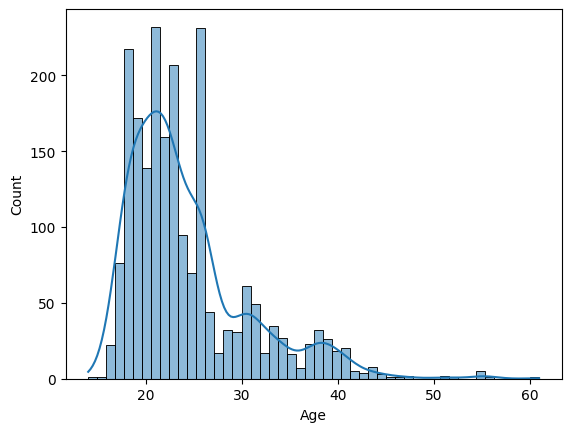

In [7]:
sns.histplot(df["Age"], kde=True)
plt.show()

<Axes: xlabel='Age'>

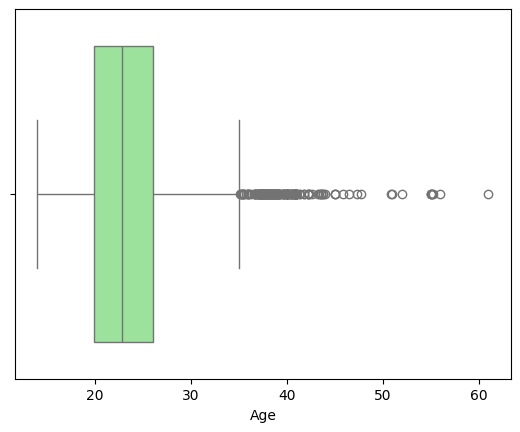

In [8]:
sns.boxplot(x=df.Age, color="lightgreen")

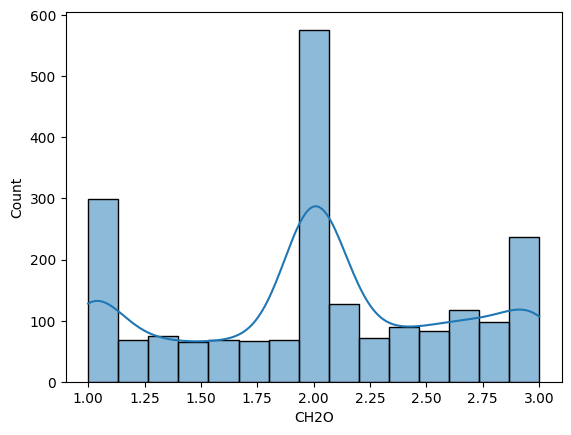

In [9]:
sns.histplot(df["CH2O"], kde=True)
plt.show()

<Axes: xlabel='CH2O'>

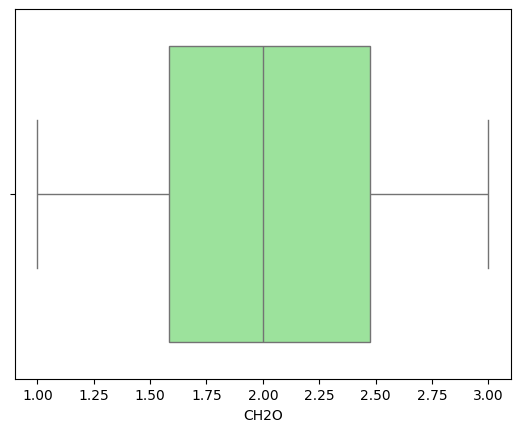

In [10]:
sns.boxplot(x=df.CH2O, color="lightgreen")

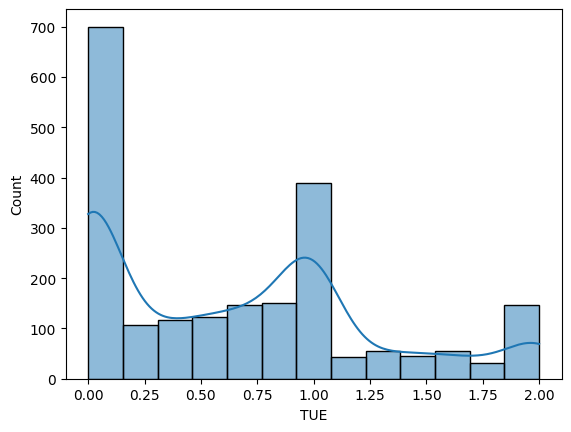

In [11]:
sns.histplot(df["TUE"], kde=True)
plt.show()

<Axes: xlabel='TUE'>

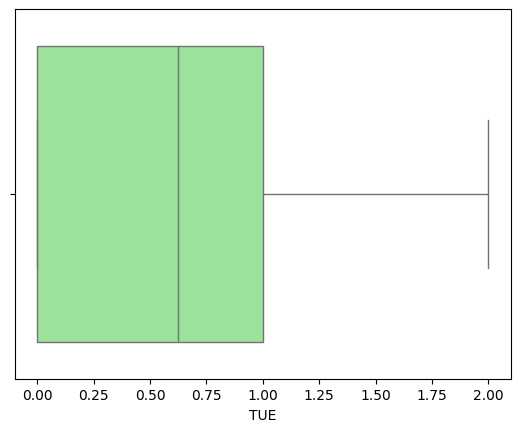

In [12]:
sns.boxplot(x=df.TUE, color="lightgreen")

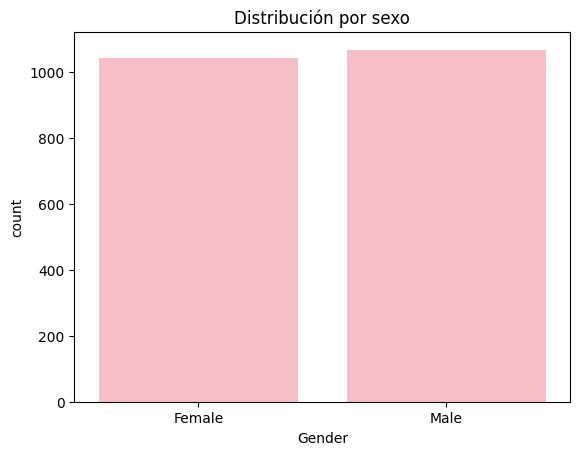

In [13]:
sns.countplot(data=df, x="Gender", color="lightpink")
plt.title("Distribución por sexo")
plt.show()

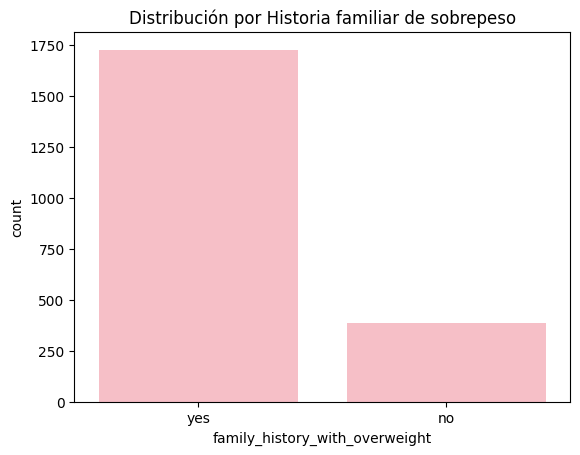

In [14]:
sns.countplot(data=df, x="family_history_with_overweight", color="lightpink")
plt.title("Distribución por Historia familiar de sobrepeso")
plt.show()

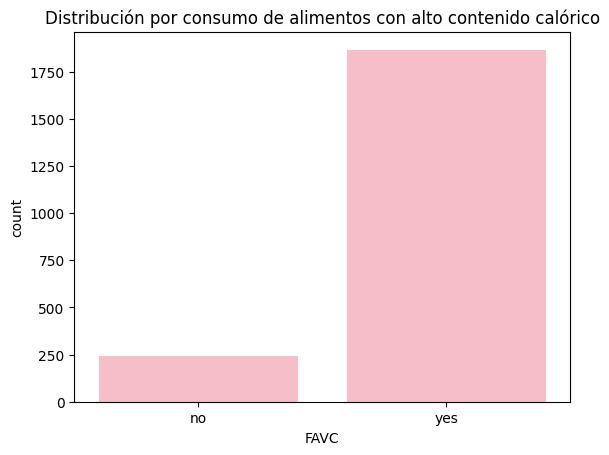

In [15]:
sns.countplot(data=df, x="FAVC", color="lightpink")
plt.title("Distribución por consumo de alimentos con alto contenido calórico")
plt.show()

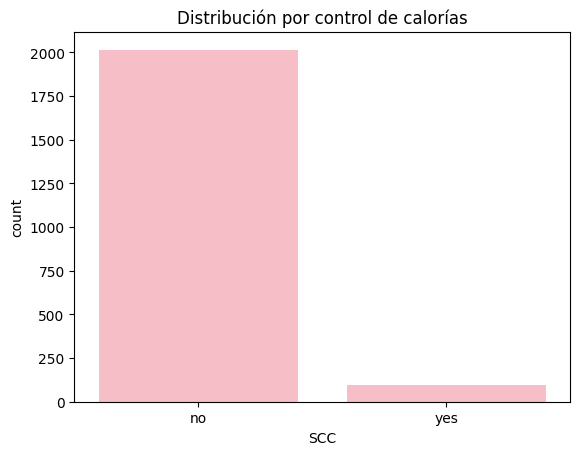

In [16]:
sns.countplot(data=df, x="SCC", color="lightpink")
plt.title("Distribución por control de calorías")
plt.show()

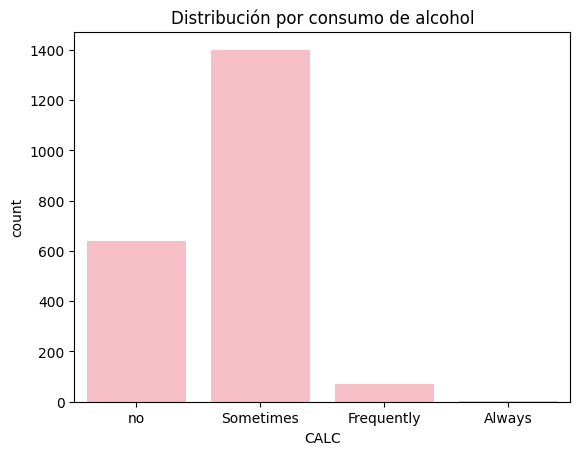

In [17]:
sns.countplot(data=df, x="CALC", color="lightpink")
plt.title("Distribución por consumo de alcohol")
plt.show()

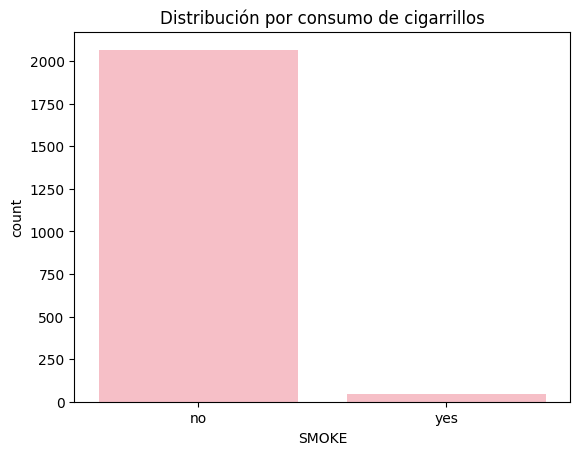

In [18]:
sns.countplot(data=df, x="SMOKE", color="lightpink")
plt.title("Distribución por consumo de cigarrillos")
plt.show()

In [19]:
cat = df.select_dtypes(include = ["str"]).columns.tolist()
df[cat].head(1)

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight


In [20]:
num=df.select_dtypes(include = ['float64']).columns.tolist()
df[num].head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0


In [21]:
corr = df[["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]].corr()
corr

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


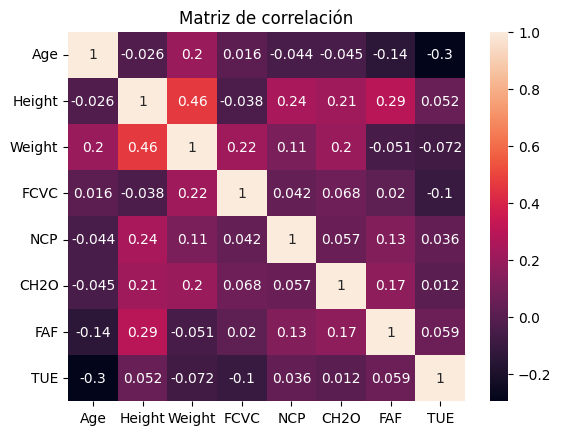

In [22]:
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

In [23]:
df.groupby('NObeyesdad').NObeyesdad.count().sort_values(ascending=False)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64

In [24]:
num.remove("Height")
num.remove("Weight")

In [25]:
cat.remove('NObeyesdad')
cat

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS']

In [26]:
df["NObeyesdad"] = LabelEncoder().fit_transform(df["NObeyesdad"])
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,1
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,1
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,1
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,5
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,6


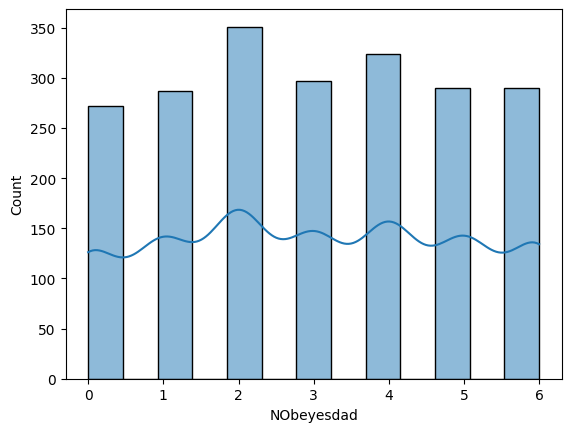

In [27]:
sns.histplot(df["NObeyesdad"], kde=True)
plt.show()

In [28]:
df =pd.get_dummies(df, drop_first=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2111 non-null   float64
 1   Height                              2111 non-null   float64
 2   Weight                              2111 non-null   float64
 3   FCVC                                2111 non-null   float64
 4   NCP                                 2111 non-null   float64
 5   CH2O                                2111 non-null   float64
 6   FAF                                 2111 non-null   float64
 7   TUE                                 2111 non-null   float64
 8   NObeyesdad                          2111 non-null   int64  
 9   Gender_Male                         2111 non-null   bool   
 10  family_history_with_overweight_yes  2111 non-null   bool   
 11  FAVC_yes                            2111 non-null   bo

In [29]:
df.head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,1,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,1,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,5,True,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,6,True,...,False,False,False,False,True,False,False,False,True,False


In [30]:
X = df.drop(columns=['NObeyesdad', 'Height', 'Weight'])
y = df['NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y.values.reshape(-1,1), train_size=0.8, random_state=0, shuffle=True)
X

,Age,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.000000,2.0,3.0,2.000000,0.000000,1.000000,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
1,21.000000,3.0,3.0,3.000000,3.000000,0.000000,False,True,False,False,...,False,True,True,False,True,False,False,False,True,False
2,23.000000,2.0,3.0,2.000000,2.000000,1.000000,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3,27.000000,3.0,3.0,2.000000,2.000000,0.000000,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,22.000000,2.0,1.0,2.000000,0.000000,0.000000,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,3.0,3.0,1.728139,1.676269,0.906247,False,True,True,False,...,False,False,False,False,True,False,False,False,True,False
2107,21.982942,3.0,3.0,2.005130,1.341390,0.599270,False,True,True,False,...,False,False,False,False,True,False,False,False,True,False
2108,22.524036,3.0,3.0,2.054193,1.414209,0.646288,False,True,True,False,...,False,False,False,False,True,False,False,False,True,False
2109,24.361936,3.0,3.0,2.852339,1.139107,0.586035,False,True,True,False,...,False,False,False,False,True,False,False,False,True,False


In [31]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

scaler = MinMaxScaler()
X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

X_train.head(2)

,Age,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
1295,0.5138,0.5000,0.6667,0.1374,0.0000,0.0000,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
1627,0.5610,0.6410,0.9235,0.0000,0.4435,0.0000,True,True,True,False,...,False,False,False,False,False,True,False,False,False,False


### **Modelos de ensamble basados en árboles**

**Random Forest**

In [54]:
resultados = []
for trees in range(10,101, 10):
    for features in range(12,17,1):
        modelo_rf = RandomForestClassifier(n_estimators=trees,criterion='entropy',max_features=features, min_samples_leaf=3, random_state=0)
        modelo_rf.fit(X_train, y_train)
        
        y_pred_rf = modelo_rf.predict(X_test)
        Yest = modelo_rf.predict(X_train)
        
        acc_test  = accuracy_score(y_test.ravel(), y_pred_rf)
        acc_train = accuracy_score(y_train.ravel(), Yest)

        resultados.append({
            'trees': trees,
            'features': features,
            'acc_train': acc_train,
            'acc_test':  acc_test
        })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(['acc_test', 'trees'], ascending=[False, True]).reset_index(drop=True)

,trees,features,acc_train,acc_test
0,30,13,0.9562,0.8558
1,30,15,0.9550,0.8440
2,50,13,0.9573,0.8440
3,70,14,0.9597,0.8440
4,70,15,0.9603,0.8440
5,20,16,0.9485,0.8416
6,80,15,0.9621,0.8416
7,90,13,0.9573,0.8416
8,100,15,0.9603,0.8416
9,30,14,0.9520,0.8392


trees       30.0000
features    13.0000
acc_train    0.9562
acc_test     0.8558
Name: 11, dtype: float64


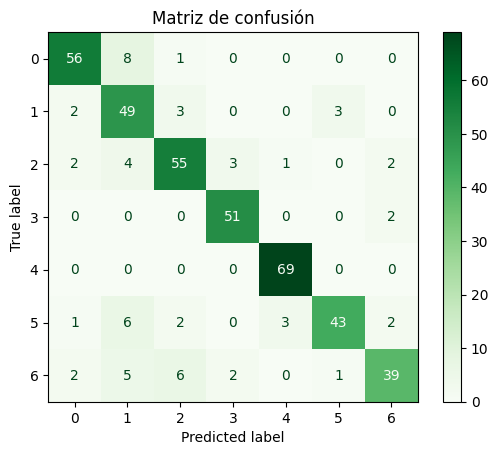

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        65
           1       0.68      0.86      0.76        57
           2       0.82      0.82      0.82        67
           3       0.91      0.96      0.94        53
           4       0.95      1.00      0.97        69
           5       0.91      0.75      0.83        57
           6       0.87      0.71      0.78        55

    accuracy                           0.86       423
   macro avg       0.86      0.85      0.85       423
weighted avg       0.86      0.86      0.86       423



In [56]:
mejor =df_resultados.loc[df_resultados['acc_test'].idxmax()]
print(mejor)
mejor_modelo_rf = RandomForestClassifier(n_estimators=int(mejor['trees']),criterion='entropy',max_features=int(mejor['features']), min_samples_leaf=3, random_state=0)
mejor_modelo_rf.fit(X_train, y_train)
y_pred_final = mejor_modelo_rf.predict(X_test) 

mc = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=mejor_modelo_rf.classes_)
disp.plot(cmap='Greens')
plt.title("Matriz de confusión")
plt.show()
print(classification_report(y_test, y_pred_final))

In [71]:
print("Validación sin ninguna técnica:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1:       {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro'):.4f}")

Validación sin ninguna técnica:
Accuracy: 0.8558
F1:       0.8529
Recall:   0.8525
Precision: 0.8611


**Validación con cross validation**

**Gradient Boosting**

In [66]:
modelo_gb = GradientBoostingClassifier(random_state=0)  
modelo_gb.fit(X_train, y_train)
y_pred_gb = modelo_gb.predict(X_test)

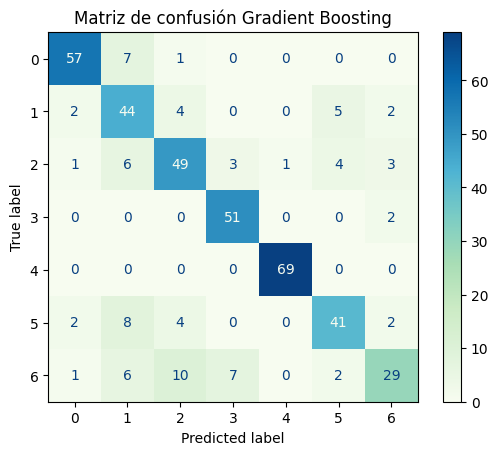

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        65
           1       0.62      0.77      0.69        57
           2       0.72      0.73      0.73        67
           3       0.84      0.96      0.89        53
           4       0.99      1.00      0.99        69
           5       0.79      0.72      0.75        57
           6       0.76      0.53      0.62        55

    accuracy                           0.80       423
   macro avg       0.80      0.80      0.80       423
weighted avg       0.81      0.80      0.80       423



In [69]:
mc_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=mc_gb, display_labels=modelo_gb.classes_)
disp.plot(cmap='GnBu')
plt.title("Matriz de confusión Gradient Boosting")
plt.show()
print(classification_report(y_test, y_pred_gb))

**Encontrar los mejores hiperparámetros con GridSearchCV**